In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Lecture 12: Dirichlet-Multinomial Inference

### Simulations from Beta and Dirichlet distributions

In [44]:
#Simulate from Beta(a, b)
a = .000002
#a = 0.5
b = .000002
#b = 0.5
beta_samples = np.random.beta(a, b, size=1000)
print(beta_samples)
print(np.mean(beta_samples))


[0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1.
 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 1.
 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0.
 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1.
 0. 1. 1. 0. 1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0. 1.
 1. 1. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 1.
 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 1. 0.
 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0.
 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 1. 1. 1. 1. 1. 0.
 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0.
 0. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1.
 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 1. 1. 0.

By setting $a = b = \epsilon$ for some small $\epsilon$ in the above code, we can check that samples from $\text{Beta}(a, b)$ are 0 or 1 with equal frequency (up to Monte Carlo error). 

By setting $a = \epsilon$ and $b$ to be a fixed positive constant (e.g., $b = 0.5$), we get all samples equal to 0. 

Analogously, by setting $a$ to be a fixed positive constant (e.g., $a = 0$) and $b = \epsilon$, we get all samples equal to 1. 

Below we obtain samples from the Dirichlet distribution with $k = 4$. 

In [51]:
#Samples from Dirichlet distribution
k = 4
#alpha = np.array([0.02, 0.02, 0.02, 0.02])
#alpha = np.array([0.5, 0.5, 0.5, 0.0002])
alpha = np.array([3, 1, 0.000002, 0.000002])
dirichlet_samples = np.random.dirichlet(alpha, size=1000)
print(dirichlet_samples)
print(np.mean(dirichlet_samples, axis=0))

[[0.86443728 0.13556272 0.         0.        ]
 [0.94432839 0.05567161 0.         0.        ]
 [0.93369658 0.06630342 0.         0.        ]
 ...
 [0.77504867 0.22495133 0.         0.        ]
 [0.94097736 0.05902264 0.         0.        ]
 [0.84199999 0.15800001 0.         0.        ]]
[7.50627682e-001 2.49372318e-001 0.00000000e+000 1.46093836e-121]


If $a_1 = a_2 = a_3 = a_4 = \epsilon$ for some small $\epsilon$, then each Dirichlet sample will be one of $(1, 0, 0, 0)$, $(0, 1, 0, 0)$, $(0, 0, 1, 0)$, $(0, 0, 0, 1)$ with equal frequency (up to Monte Carlo error). 

If $a_1, a_2, a_3$ are some fixed numbers (not small) and $a_4 = \epsilon$ for a small $\epsilon$, then $p_4$ will be zero in every sample, and the other three $(p_1, p_2, p_3)$ are drawn from Dirichlet$(a_1, a_2, a_3)$. 

If $a_1, a_2$ are fixed numbers (not small) and $a_3 = a_4 = \epsilon$ for a small $\epsilon$, then $p_3, p_4$ will be zero in every sample, and the other two $(p_1, p_2)$ are drawn from Dirichlet$(a_1, a_2)$. 

## A simple problem to illustrate Dirichlet-Multinomial Inference

Consider the following problem that we already studied previously (see e.g., Lecture 4): 

*Suppose a scientist makes 6 numerical measurements $26.6, 38.5, 34.4, 34, 31, 23.6$ on an unknown real-valued physical quantity $\theta$. On the basis of these measurements, what can be inferred about $\theta$?*

Previously we solved this problem using the Bayesian model: 
\begin{align*}
   X_1, \dots, X_n \mid \theta,\sigma \overset{\text{i.i.d}}{\sim} N(\theta, \sigma^2)~~ \text{ and }~~ \theta, \log \sigma \overset{\text{i.i.d}}{\sim} \text{uniform}(-\infty, \infty). 
\end{align*}
This gave the following posterior for $\theta$: 
\begin{align*}
   \frac{\sqrt{n}(\theta - \hat{\theta})}{\sqrt{S(\hat{\theta})/(n-1)}} \mid \text{data} \sim t_{n-1}
\end{align*}
where $S(\theta) := \sum_{i=1}^n (x_i - \theta)^2$ and $\hat{\theta} = \bar{x} = (x_1 + \dots + x_n)/n$. This led to the 95% interval: $[25.598, 37.102]$. 

We now use the model: 
\begin{align*}
    X_1, \dots, X_n \mid P \overset{\text{i.i.d}}{\sim} P ~~ \text{ and } ~~ \theta = \text{mean corresponding to} ~ P
\end{align*}
We use discretization and assume that $P$ is supported on a large finite set $G = \{g_1, \dots, g_k\}$ e.g., $G = \{0.1, 0.2, \dots, 99.9, 100.0\}$. Let the probabilities assigned by $P$ to $g_1, \dots, g_k$ be $p_1, \dots, p_k$. We use the noninformative prior: 
\begin{align*}
   (p_1, \dots, p_k) \sim \text{Dirichlet}(0, \dots, 0). 
\end{align*}
This leads to the posterior: 
\begin{align*}
  P \mid X_1 = x_1, \dots, X_n = x_n \sim \sum_{i=1}^n w_i \delta_{\{x_i\}} ~\text{where} ~ (w_1, \dots, w_n) \sim \text{Dirichlet}(1, \dots, 1). 
\end{align*}
The posterior of $\theta$ is therefore: 
\begin{align*}
   \theta \mid \text{data} \sim \sum_{i=1}^n w_i x_i \text{ where } (w_1, \dots, w_n) \sim \text{Dirichlet}(1, \dots, 1). 
\end{align*}
Below we simulate from this posterior, and obtain posterior mean and 95\% credible interval.

In [34]:
x_obs = np.array([26.6, 38.5, 34.4, 34, 31, 23.6])
n = len(x_obs)
M = 100000 #number of posterior samples
np.random.seed(42) #for reproducibility
W = np.random.dirichlet(alpha = np.ones(n), size=M) #M samples from the Dirichlet distribution
theta_samples = W @ x_obs #compute the posterior samples of theta

theta_mean = np.mean(theta_samples)
theta_ci = np.quantile(theta_samples, [0.025, 0.975])

print(f"Posterior mean of theta: {theta_mean:.2f}")
print(f"95% credible interval: [{theta_ci[0]:.2f}, {theta_ci[1]:.2f}]")

Posterior mean of theta: 31.35
95% credible interval: [27.53, 34.90]


Below is a histogram of all the posterior samples. 

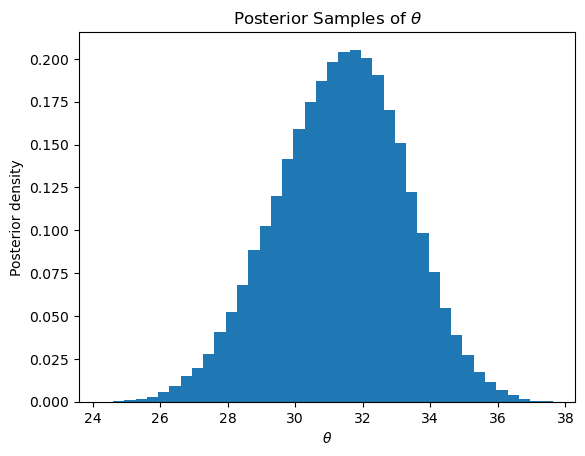

In [35]:
plt.hist(theta_samples, bins=40, density=True)
plt.xlabel(r"$\theta$")
plt.ylabel("Posterior density")
plt.title("Posterior Samples of $\\theta$")
plt.show()

This method is actually the Bayesian bootstrap because it is very close to the bootstrap operationally. We shall see these connections in the next lecture. 